# Analisi dei fattori che influenzano il valore di mercato dei calciatori nei cinque principali campionati europei

## Introduzione


Ho scelto questo argomento perché seguo e gioco a calcio e conosco molto bene **Transfermarkt** dove sono presenti anche dati relativi al mio profilo, rendendo il progetto ancora più personale.

<div style="text-align:center; margin-top:25px;">
<img src="profilo_transfermarkt.png" width="430">
</div>

## Obiettivo dello studio

L'obiettivo del progetto è capire quali caratteristiche sono maggiormente associate al valore di mercato dei calciatori.

**Domanda principale**

Quali fattori influenzano maggiormente il valore di mercato dei giocatori dei cinque principali campionati europei?

L'analisi considera:
- campionato
- ruolo
- età

## Dataset utilizzato

Per questo progetto sono stati utilizzati dati pubblici provenienti da **Transfermarkt**, una delle principali piattaforme dedicate al calcio professionistico.

- **players.csv**: informazioni anagrafiche e tecniche dei giocatori;


**Fonte**: David Cariboo, Football Data from Transfermarkt (Kaggle)

**Disponibile online**: Kaggle

**Link**: https://www.kaggle.com/datasets/davidcariboo/player-scores/data

In [271]:
import pandas as pd
import matplotlib.pyplot as plt

## Caricamento dei dati

In [272]:
players = pd.read_csv("../data/raw/players.csv")

## Esplorazione del dataset

Prima di procedere con l'analisi è necessario comprendere la struttura del dataset e verificare la presenza di eventuali valori mancanti.

In [273]:
print("Players:", players.shape)

Players: (48380, 26)


In [274]:
players.info()

<class 'pandas.DataFrame'>
RangeIndex: 48380 entries, 0 to 48379
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             48380 non-null  int64  
 1   first_name                            45255 non-null  str    
 2   last_name                             48380 non-null  str    
 3   name                                  48380 non-null  str    
 4   last_season                           48380 non-null  int64  
 5   current_club_id                       48380 non-null  int64  
 6   player_code                           48380 non-null  str    
 7   country_of_birth                      43065 non-null  str    
 8   city_of_birth                         43343 non-null  str    
 9   country_of_citizenship                48109 non-null  str    
 10  date_of_birth                         48331 non-null  str    
 11  sub_position              

In [275]:
players.describe()

,player_id,last_season,current_club_id,height_in_cm,international_caps,international_goals,current_national_team_id,market_value_in_eur,highest_market_value_in_eur
count,4.838000e+04,48380.000000,48380.000000,44597.000000,18355.000000,18355.000000,5614.000000,4.150600e+04,4.150600e+04
mean,4.907818e+05,2021.509301,8510.434932,181.974841,11.666903,1.207791,7478.395440,1.511445e+06,3.452120e+06
std,3.719325e+05,4.256063,17414.750874,7.432188,19.198009,4.195957,6906.475976,5.855964e+06,9.349555e+06
min,1.000000e+01,2012.000000,2.000000,17.000000,0.000000,0.000000,3262.000000,1.000000e+04,1.000000e+04
25%,1.799545e+05,2018.000000,511.000000,177.000000,1.000000,0.000000,3499.000000,1.000000e+05,3.000000e+05
50%,4.057930e+05,2024.000000,1506.000000,182.000000,4.000000,0.000000,3672.000000,2.750000e+05,7.500000e+05
75%,7.359592e+05,2025.000000,6890.000000,187.000000,12.000000,1.000000,10533.000000,7.000000e+05,2.500000e+06
max,1.555760e+06,2025.000000,142301.000000,210.000000,229.000000,143.000000,53982.000000,2.000000e+08,2.000000e+08


In [276]:
players.isnull().sum()

player_id                                   0
first_name                               3125
last_name                                   0
name                                        0
last_season                                 0
current_club_id                             0
player_code                                 0
country_of_birth                         5315
city_of_birth                            5037
country_of_citizenship                    271
date_of_birth                              49
sub_position                              505
position                                    0
foot                                     5288
height_in_cm                             3783
contract_expiration_date                16632
agent_name                              22517
image_url                                   0
international_caps                      30025
international_goals                     30025
current_national_team_id                42766
url                               

## Preparazione del dataset

Il database originale contiene giocatori appartenenti a numerosi campionati professionistici.

Poiché l'obiettivo di questo studio è analizzare il calcio di massimo livello, l'analisi verrà limitata ai cinque principali campionati europei:

- Premier League
- Serie A
- LaLiga
- Bundesliga
- Ligue 1

Questa scelta permette di confrontare giocatori appartenenti a contesti sportivi simili e rende il campione più omogeneo.

In [277]:
top5 = ["IT1", "GB1", "ES1", "L1", "FR1"]
players_top5 = players[ players ["current_club_domestic_competition_id"].isin(top5) ].copy()

In [278]:
players_top5.shape

(11335, 26)

### Selezione del campione

Il dataset originale comprende giocatori appartenenti a numerosi campionati professionistici.

Per rendere l'analisi più omogenea sono stati mantenuti esclusivamente i calciatori appartenenti ai cinque principali campionati europei (Premier League, Serie A, LaLiga, Bundesliga e Ligue 1).

Questa scelta permette di confrontare giocatori che operano in contesti sportivi di livello simile e rende più significativi i risultati ottenuti.

In [279]:
players_top5 = players_top5[
    [
        "player_id",
        "name",
        "current_club_name",
        "current_club_domestic_competition_id",
        "position",
        "sub_position",
        "foot",
        "height_in_cm",
        "date_of_birth",
        "market_value_in_eur",
        "highest_market_value_in_eur"
    ]
].copy()

### Selezione delle variabili

Sono state mantenute solamente le variabili ritenute utili per rispondere alla domanda di ricerca.

In particolare verranno analizzate informazioni anagrafiche, caratteristiche tecniche e valore di mercato dei calciatori.

In [280]:
players_top5["date_of_birth"] = pd.to_datetime( players_top5["date_of_birth"] )

players_top5["age"] = ( 2025 - players_top5["date_of_birth"].dt.year )

In [281]:
players_top5.drop(columns="date_of_birth", inplace=True)

In [282]:
players_top5 = players_top5.dropna( subset=["market_value_in_eur"] )

In [283]:
players_top5.info()

<class 'pandas.DataFrame'>
Index: 10735 entries, 0 to 48314
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             10735 non-null  int64  
 1   name                                  10735 non-null  str    
 2   current_club_name                     10735 non-null  str    
 3   current_club_domestic_competition_id  10735 non-null  str    
 4   position                              10735 non-null  str    
 5   sub_position                          10716 non-null  str    
 6   foot                                  10150 non-null  str    
 7   height_in_cm                          10162 non-null  float64
 8   market_value_in_eur                   10735 non-null  float64
 9   highest_market_value_in_eur           10735 non-null  float64
 10  age                                   10714 non-null  float64
dtypes: float64(4), int64(1), str(6)

In [284]:
players_top5.head()

,player_id,name,current_club_name,current_club_domestic_competition_id,position,sub_position,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,age
0,10,Miroslav Klose,Società Sportiva Lazio S.p.A.,IT1,Attack,Centre-Forward,right,184.0,1000000.0,30000000.0,47.0
1,26,Roman Weidenfeller,Borussia Dortmund,L1,Goalkeeper,Goalkeeper,left,190.0,750000.0,8000000.0,45.0
3,77,Lúcio,Juventus Football Club,IT1,Defender,Centre-Back,NaN,NaN,200000.0,24500000.0,47.0
4,80,Tom Starke,FC Bayern München,L1,Goalkeeper,Goalkeeper,right,194.0,100000.0,3000000.0,44.0
6,123,Christoph Metzelder,FC Schalke 04,L1,Defender,Centre-Back,NaN,NaN,1500000.0,9500000.0,45.0


## Dataset finale

Al termine della fase di preparazione è stato ottenuto un dataset contenente esclusivamente i calciatori appartenenti ai cinque principali campionati europei e dotati di un valore di mercato disponibile.
Il dataset finale costituisce la base per tutte le analisi successive.

**Campione finale**

Giocatori analizzati: 10735

Campionati analizzati: 5

# Domanda 1

## Com'è composto il campione analizzato?

Prima di analizzare il valore di mercato è utile comprendere come è distribuito il campione tra i cinque principali campionati europei.


In [285]:
league_names = {
    "IT1": "Serie A",
    "GB1": "Premier League",
    "ES1": "LaLiga",
    "L1": "Bundesliga",
    "FR1": "Ligue 1"
}

players_top5["league"] = players_top5[ "current_club_domestic_competition_id" ].map(league_names)

In [286]:
league_counts = ( players_top5["league"] .value_counts() )

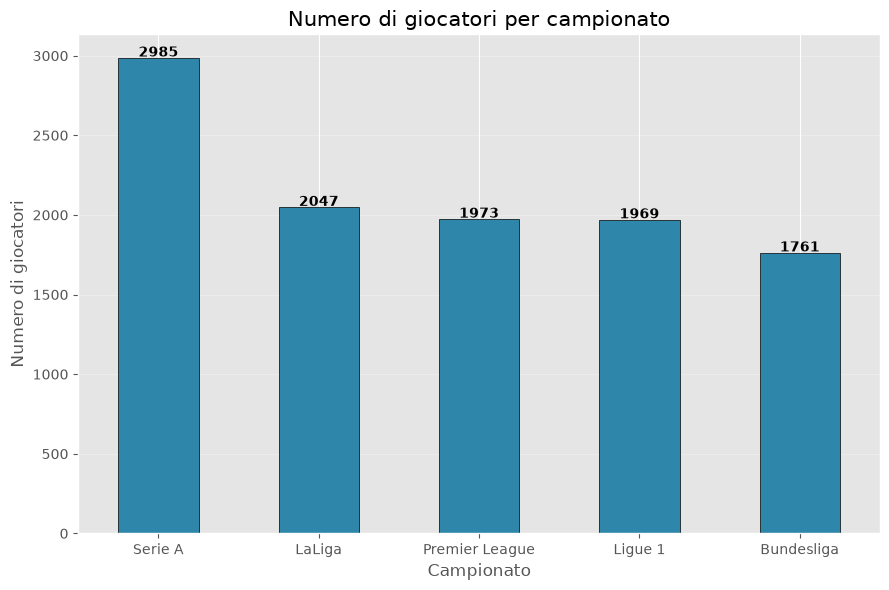

In [287]:
plt.figure(figsize=(9,6))

ax = league_counts.plot( kind="bar", color="#2E86AB", edgecolor="black" )
plt.title("Numero di giocatori per campionato", fontsize=15)
plt.xlabel("Campionato")
plt.ylabel("Numero di giocatori")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for i, valore in enumerate(league_counts):
    ax.text(
        i,
        valore + 10,
        str(valore),
        ha="center",
        fontweight="bold"
    )
plt.tight_layout()
plt.show()

### Interpretazione

La presenza di un numero elevato di osservazioni per ciascun campionato rende il campione adeguato per le analisi successive.

# Domanda 2

## Il campionato influenza il valore di mercato dei calciatori?

Questa analisi permette di capire se alcuni campionati concentrano mediamente giocatori con valutazioni economiche più elevate rispetto ad altri.

In [288]:
average_league_value = ( players_top5.groupby("league")["market_value_in_eur"].mean().sort_values(ascending=False)/ 1_000_000 )

average_league_value

league
Premier League    7.183877
Bundesliga        3.301618
LaLiga            3.052469
Ligue 1           2.802227
Serie A           2.092563
Name: market_value_in_eur, dtype: float64

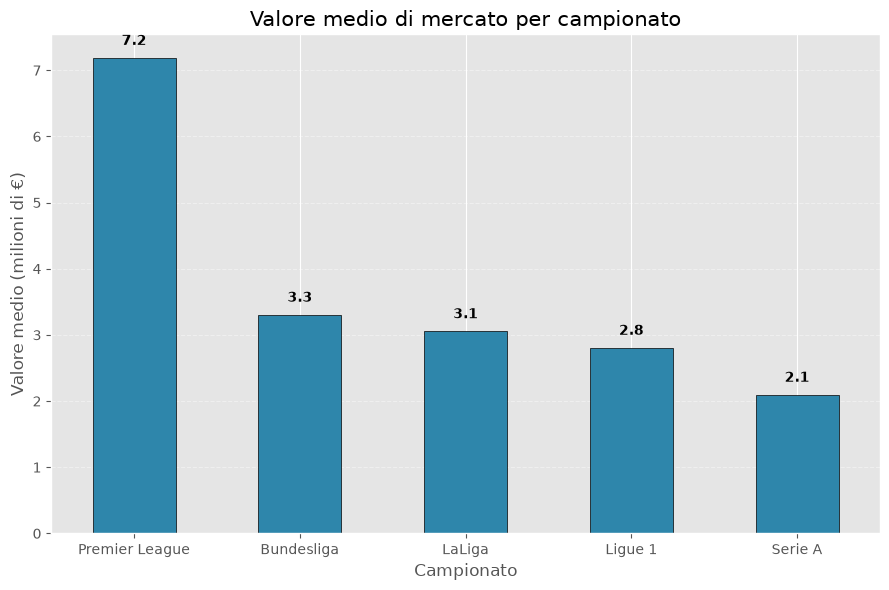

In [289]:
plt.figure(figsize=(9,6))
ax = average_league_value.plot( kind="bar", color="#2E86AB", edgecolor="black" )
plt.title("Valore medio di mercato per campionato", fontsize=15)
plt.xlabel("Campionato")
plt.ylabel("Valore medio (milioni di €)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
# Valori sopra ogni barra
for i, valore in enumerate(average_league_value):
    ax.text(
        i,
        valore + 0.2,
        f"{valore:.1f}",
        ha="center",
        fontweight="bold"
    )
plt.tight_layout()
plt.show()

### Interpretazione

La Premier League presenta il valore medio più elevato, mentre la Serie A quello più basso.

# Domanda 3

## Il ruolo influenza il valore di mercato?

Sono stati considerati solamente i calciatori con un valore di mercato pari o superiore a **1 milione di euro**, escludendo le valutazioni più basse che potrebbero alterare il confronto tra i diversi ruoli.

In [290]:
players_roles = players_top5[ players_top5["position"].notna() & (players_top5["position"] != "Missing") ].copy()

role_value = ( players_roles.groupby("position")["market_value_in_eur"].mean().sort_values(ascending=False) / 1_000_000 )

role_value

position
Attack        4.511527
Midfield      3.947654
Defender      3.258959
Goalkeeper    1.371742
Name: market_value_in_eur, dtype: float64

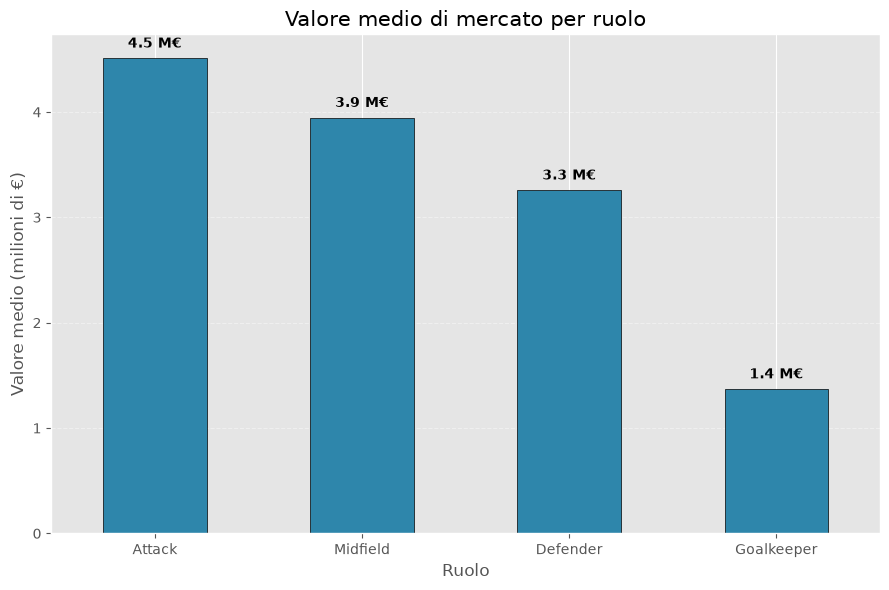

In [291]:
plt.figure(figsize=(9,6))
ax = role_value.plot( kind="bar", color="#2E86AB", edgecolor="black" )
plt.title("Valore medio di mercato per ruolo", fontsize=15)
plt.xlabel("Ruolo")
plt.ylabel("Valore medio (milioni di €)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=0)
# Valore sopra ogni barra
for i, valore in enumerate(role_value):
    ax.text(
        i,
        valore + 0.1,
        f"{valore:.1f} M€",
        ha="center",
        fontweight="bold"
    )
plt.tight_layout()
plt.show()

### Interpretazione

Gli attaccanti presentano il valore medio più alto, mentre i portieri quello più basso.

# Domanda 4

## Il valore di mercato varia in base all'età?

I calciatori vengono suddivisi in fasce di età e viene calcolato il valore medio di mercato per ciascuna fascia.

In [292]:
bins = [15, 21, 25, 29, 33, 45]

labels = [ "16-21", "22-25", "26-29", "30-33", "34+" ]

players_top5["age_group"] = pd.cut( players_top5["age"], bins=bins, labels=labels )

In [293]:
age_value = ( players_top5.groupby("age_group")["market_value_in_eur"].mean() / 1_000_000 )

age_value

age_group
16-21    6.677619
22-25    7.024631
26-29    4.662407
30-33    1.337705
34+      0.471865
Name: market_value_in_eur, dtype: float64

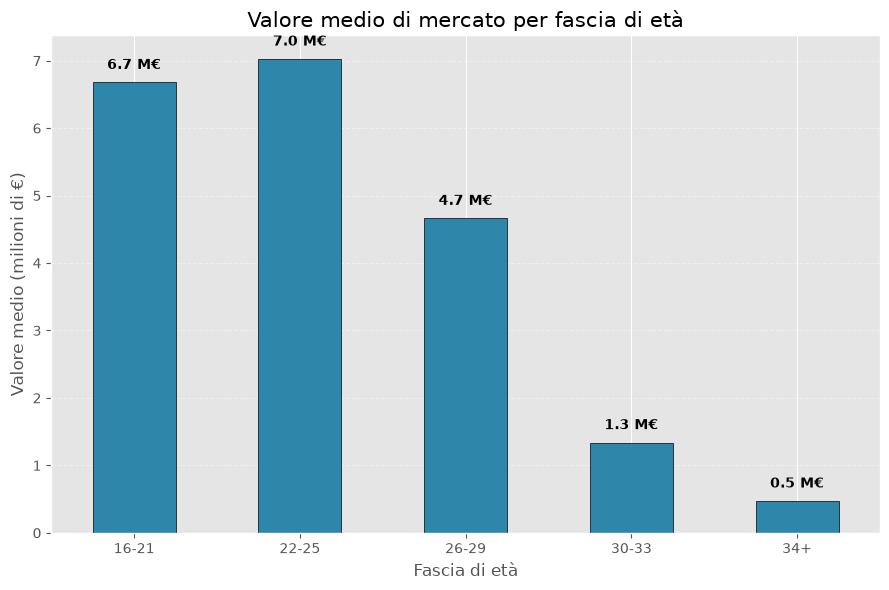

In [294]:
plt.figure(figsize=(9,6))

ax = age_value.plot( kind="bar", color="#2E86AB", edgecolor="black" )

plt.title("Valore medio di mercato per fascia di età", fontsize=15)
plt.xlabel("Fascia di età")
plt.ylabel("Valore medio (milioni di €)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for i, valore in enumerate(age_value):
    ax.text(
        i,
        valore + 0.2,
        f"{valore:.1f} M€",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Interpretazione

Il grafico mostra come i valori di mercato più alti si verfiicano nella fascia di età tra i 16-25 anni.

# Conclusioni

L’obiettivo del progetto era individuare quali caratteristiche influenzano il valore di mercato dei calciatori dei cinque principali campionati europei.

Dalle analisi sono emersi questi risultati:

- il valore di mercato varia tra i diversi campionati;
- il ruolo del calciatore influisce sul valore di mercato;
- l’età rappresenta un fattore importante;

In conclusione, il valore di mercato dipende dalla combinazione di età, ruolo e dal campionato in cui si gioca .
L’analisi dei dati permette quindi di individuare i principali fattori associati al valore economico dei calciatori

In [295]:
!jupyter nbconvert notebook.ipynb --to slides --no-input --SlidesExporter.reveal_number='c/t' --SlidesExporter.reveal_scroll=True --embed-images

[NbConvertApp] Converting notebook notebook.ipynb to slides
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 1179269 bytes to notebook.slides.html
